In [8]:
from models.model_pretrain import CrossViewLM

from transformers import AutoConfig
import omegaconf, os
# /dscilab_dungvo/workspace/BA-PRE_THESIS/paper_clone_2/X2_VLM_Forked/configs/pretrain/multilingual_cclm_x2vlm_base.yaml
config_path = '/dscilab_dungvo/workspace/BA-PRE_THESIS/paper_clone_2/X2_VLM_Forked/configs/pretrain/multilingual_cclm_x2vlm_base.yaml'
config = omegaconf.OmegaConf.load(config_path)
# checkpoint = 'x2vlm_base_1b.th'
checkpoint = "cclm_x2vlm_base"

# print config as multilines yaml
# print(omegaconf.OmegaConf.to_yaml(config))
# root = ''
# for config_name in [config['text_encoder'], config['cross_encoder']]:
#     config_path = os.path.join(root, config_name)
#     rectify_path = config_path.replace('#', '/')
#     temp_config = AutoConfig.from_pretrained(config_path.split('/')[-1].replace('#', '/'))
#     print(temp_config)
#     temp_config.save_pretrained(rectify_path)
#     print(f'Saved config to {rectify_path}')

In [9]:
# from transformers import AutoTokenizer, XLMRobertaTokenizer
# tokenizer = XLMRobertaTokenizer.from_pretrained('facebookai/xlm-roberta-base')
# tokenizer.save_pretrained('data/xlm-roberta-base')

# config['model_type']

In [10]:
# # config['text_encoder'] = 'data/xlm-roberta-base'
# # download the model pytorch_model.bin to data/xlm-roberta-base

# from transformers import AutoModel
# import torch
# model = AutoModel.from_pretrained('facebookai/xlm-roberta-base', config=config['text_encoder'])
# # model.save_pretrained('data/xlm-roberta-base')
# torch.save(model.state_dict(), 'data/xlm-roberta-base/pytorch_model.bin')

In [131]:
# config['text_encoder']

'data/xlm-roberta-base'

In [5]:
# whole_checkpoint = 'x2vlm_base_1b.th'
import torch
whole_checkpoint = "cclm_x2vlm_base.th"

whole_state_dict = torch.load(whole_checkpoint, map_location='cpu')
model_state_dict = whole_state_dict['model']

# rename cclm_x2vlm_base.th to checkpoints/whole_training/cclm_x2vlm_base.pth
# if not os.path.exists('checkpoints/whole_training'):
#     os.makedirs('checkpoints/whole_training')
    
# if not os.path.exists('checkpoints/model'):
#     os.makedirs('checkpoints/model')
    
# torch.save(whole_state_dict, f'checkpoints/whole_training/{whole_checkpoint}')
# torch.save(model_state_dict, f'checkpoints/model/{whole_checkpoint}')

/tmp/ipykernel_1220579/2815496314.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  whole_state_dict = torch.load(whole_checkpoint, map_location='cpu')


In [25]:
config

{'train_file': ['path/to/cc-3m-mm-uc2', 'path/to/sbu-mm', 'path/to/vg-mm', 'path/to/coco-mm'], 'train_dataset_size': 5004332, 'images': {'image_key': 'binary', 'is_image_rpath': False, 'caption_key': 'caption', 'tokenized': False, 'batch_size': 60, 'num_workers': 4, 'iter_perc': 1.0}, 'train_file_regions': ['path/to/coco_object-mm-google', 'path/to/vg_object-mm-google', 'path/to/vg_region-mm'], 'regions': {'image_key': 'binary', 'is_image_rpath': False, 'caption_key': 'caption', 'tokenized': False, 'code_switch': True, 'careful_hflip': True, 'batch_size': 60, 'max_images': 26, 'max_regions': 5, 'min_perc_in_image': 0.5, 'num_workers': 4}, 'train_file_mtext': ['path/to/wikimatrix', 'path/to/wikimatrix_en_bn'], 'mtexts': {'source_key': 'source_text', 'target_key': 'target_text', 'tokenized': False, 'batch_size': 60, 'num_workers': 4, 'iter_perc': 1.0, 'max_words': 64, 'max_tokens': 64, 'mask_prob': 0.4, 'max_masks': 16}, 'use_beit_v2': True, 'vision_config': 'configs/config_beit2_base.js

In [6]:
whole_state_dict['config']

{'train_file': ['hdfs://haruna/home/byte_ailab_litg/user/zengyan/vlm/images/cc-3m-mm-uc2',
  'hdfs://haruna/home/byte_ailab_litg/user/zengyan/vlm/images/sbu-mm',
  'hdfs://haruna/home/byte_ailab_litg/user/zengyan/vlm/images/vg-mm',
  'hdfs://haruna/home/byte_ailab_litg/user/zengyan/vlm/images/coco-mm'],
 'train_dataset_size': 5004332,
 'images': {'image_key': 'binary',
  'is_image_rpath': False,
  'caption_key': 'caption',
  'tokenized': False,
  'batch_size': 64,
  'num_workers': 4,
  'iter_perc': 1.0},
 'train_file_regions': ['hdfs://haruna/home/byte_ailab_litg/user/zengyan/vlm/images/coco_object-mm-google',
  'hdfs://haruna/home/byte_ailab_litg/user/zengyan/vlm/images/vg_object-mm-google',
  'hdfs://haruna/home/byte_ailab_litg/user/zengyan/vlm/images/vg_region-mm'],
 'regions': {'image_key': 'binary',
  'is_image_rpath': False,
  'caption_key': 'caption',
  'tokenized': False,
  'code_switch': True,
  'careful_hflip': True,
  'batch_size': 64,
  'max_images': 28,
  'max_regions': 5,

In [16]:
def create_default_model():
    import sys
    sys.path.append('/dscilab_dungvo/workspace/BA-PRE_THESIS/paper_clone_2/X2_VLM_Forked')
    
    import torch
    from transformers import AutoTokenizer
    from models.model_pretrain import CrossViewLM
    from transformers import AutoConfig
    import omegaconf, os

    config_path = '/dscilab_dungvo/workspace/BA-PRE_THESIS/paper_clone_2/X2_VLM_Forked/configs/pretrain/multilingual_cclm_x2vlm_base.yaml'
    config = omegaconf.OmegaConf.load(config_path)
    whole_checkpoint = "cclm_x2vlm_base.th"
    # whole_state_dict = torch.load(whole_checkpoint, map_location='cpu')
    # model_state_dict = whole_state_dict['model']
    checkpoint = f'checkpoints/model/{whole_checkpoint}'
    config['replace_text_encoder'] = True
    assert os.path.exists(checkpoint)
    model = CrossViewLM(config=config, load_text_params=False, load_vision_params=False, load_cross_params=False,
                        pretraining=False)
    # text_ckpt_rpath = ''
    # if config.get('replace_text_encoder', True):
    #     text_ckpt_rpath = os.path.join(config['text_encoder'], 'pytorch_model.bin')
    # msg = model.load_pretrained(checkpoint, config, text_ckpt_rpath='text_ckpt_rpath')
    msg = model.load_state_dict(torch.load(checkpoint))
    model.tokenizer = AutoTokenizer.from_pretrained(config['text_encoder'])
    print(msg)
    del model.cross_encoder, model.itm_head, model.bbox_head, model.mlm_head
    return model

model = create_default_model()

Error: config_text is not BertConfig instance
### X-VLM, num_text_layers:  12
### text_drop_path_rate: 0.0, cross_drop_path_rate: 0.0
### drop path rate:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
### X-VLM, num_cross_layers:  6


/tmp/ipykernel_1223289/2337102840.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  msg = model.load_state_dict(torch.load(checkpoint))


<All keys matched successfully>


In [17]:
model


CrossViewLM(
  (vision_encoder): VisionTransformer(
    (avgpool): AdaptiveAvgPool1d(output_size=1)
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (blocks): ModuleList(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=False)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=

In [18]:
model.temp

Parameter containing:
tensor(0.0174, requires_grad=True)

In [19]:
def encode_text(model, text, max_length=30, padding='max_length', truncation=True, return_tensors='pt'):
    with torch.no_grad():
        print(text)
        model.to('cuda')
        input = model.tokenizer(text, max_length=max_length, padding=padding, truncation=truncation, return_tensors=return_tensors).to('cuda')
        text_ids = input['input_ids']
        text_atts = input['attention_mask']
        
        text_embeds = model.get_text_embeds(text_ids, text_atts)
        text_feat = model.get_features(text_embeds=text_embeds)
        return text_feat

In [20]:
model.eval()

texts = [
    "The woman is talking on the phone. Her dog is eating fried chicken.",
    "The children is swimming in the pool, in the park there are many trees.",
    "The dog is standing on the bus. He is looking out the window.",
    "The teacher is teaching the students. The students are listening to the teacher.",
    "The street is crowded with people. The cars are moving slowly.",
    "The sky is dark and full of clouds. The sun is shining brightly.",
    "The zoo is full of animals. The children are playing with the animals.",
    "The cinema is showing a movie. The audience is watching the movie.",
    "The restaurant is full of people. The waiters are serving the customers.",
    "The rainbows are colorful. The sky is bright and clear.",
    "The mountains are high and covered with snow. The rivers are flowing fast.",
    "A cat with a dog is running on the grass. The cat is chasing the dog.",
    "An old man is sitting on a bench. He is reading a newspaper.",
    "A mouse is eating cheese. The cat is watching the mouse.",
    "The person is wearing a red shirt, blue jeans and white shoes. He is walking on the street.",
    "The person is wearing a yellow shirt, black pants and brown shoes. He is standing on the sidewalk.",
]
vi_texts = [
    "Người phụ nữ đang gọi điện thoại. Con chó của cô ấy đang ăn gà rán.",
    "Những đứa trẻ đang bơi ở hồ bơi, trong công viên có nhiều cây.",
    "Con chó đang đứng trên xe buýt. Nó đang nhìn ra cửa sổ.",
    "Giáo viên đang dạy học sinh. Các học sinh đang nghe giáo viên.",
    "Đường phố đông người. Các xe đang di chuyển chậm chạp.",
    "Bầu trời tối và đầy mây. Mặt trời đang chiếu sáng rực rỡ.",
    "Vườn thú đầy động vật. Các em nhỏ đang chơi với các con vật.",
    "Rạp chiếu phim đang chiếu một bộ phim. Khán giả đang xem phim.",
    "Nhà hàng đông người. Các phục vụ đang phục vụ khách hàng.",
    "Cầu vồng rất màu sắc. Bầu trời sáng và trong.",
    "Những ngọn núi cao và phủ đầy tuyết. Những con sông đang chảy nhanh.",
    "Một con mèo với một con chó đang chạy trên cỏ. Con mèo đang đuổi theo con chó.",
    "Một ông già đang ngồi trên ghế. Ông ấy đang đọc báo.",
    "Một con chuột đang ăn phô mai. Con mèo đang nhìn con chuột.",
    "Người đàn ông đang mặc áo sơ mi đỏ, quần jean xanh và giày trắng. Anh ấy đang đi bộ trên đường.",
    "Người đàn ông đang mặc áo sơ mi vàng, quần đen và giày nâu. Anh ấy đang đứng trên vỉa hè.",
]


vi_emb = encode_text(model, vi_texts)
text_embs = encode_text(model, texts)
scores = vi_emb @ text_embs.T / model.temp
scores = scores.softmax(dim=1)
scores = scores.detach().cpu()

import pandas as pd
table_result = pd.DataFrame(scores.cpu().numpy(), columns=texts, index=vi_texts)

['Người phụ nữ đang gọi điện thoại. Con chó của cô ấy đang ăn gà rán.', 'Những đứa trẻ đang bơi ở hồ bơi, trong công viên có nhiều cây.', 'Con chó đang đứng trên xe buýt. Nó đang nhìn ra cửa sổ.', 'Giáo viên đang dạy học sinh. Các học sinh đang nghe giáo viên.', 'Đường phố đông người. Các xe đang di chuyển chậm chạp.', 'Bầu trời tối và đầy mây. Mặt trời đang chiếu sáng rực rỡ.', 'Vườn thú đầy động vật. Các em nhỏ đang chơi với các con vật.', 'Rạp chiếu phim đang chiếu một bộ phim. Khán giả đang xem phim.', 'Nhà hàng đông người. Các phục vụ đang phục vụ khách hàng.', 'Cầu vồng rất màu sắc. Bầu trời sáng và trong.', 'Những ngọn núi cao và phủ đầy tuyết. Những con sông đang chảy nhanh.', 'Một con mèo với một con chó đang chạy trên cỏ. Con mèo đang đuổi theo con chó.', 'Một ông già đang ngồi trên ghế. Ông ấy đang đọc báo.', 'Một con chuột đang ăn phô mai. Con mèo đang nhìn con chuột.', 'Người đàn ông đang mặc áo sơ mi đỏ, quần jean xanh và giày trắng. Anh ấy đang đi bộ trên đường.', 'Người

In [21]:
vi_emb.shape, text_embs.shape, scores.shape

(torch.Size([16, 256]), torch.Size([16, 256]), torch.Size([16, 16]))

In [22]:
acc = scores.argmax(dim=1) == torch.arange(len(vi_texts))
acc.sum() / len(vi_texts)
k = 3
top_k_acc = torch.topk(scores, k).indices == torch.arange(len(vi_texts)).unsqueeze(1)
top_k_acc.sum() / len(vi_texts)

tensor(0.8125)

In [23]:
len(vi_texts) - len(texts)

0

<Axes: >

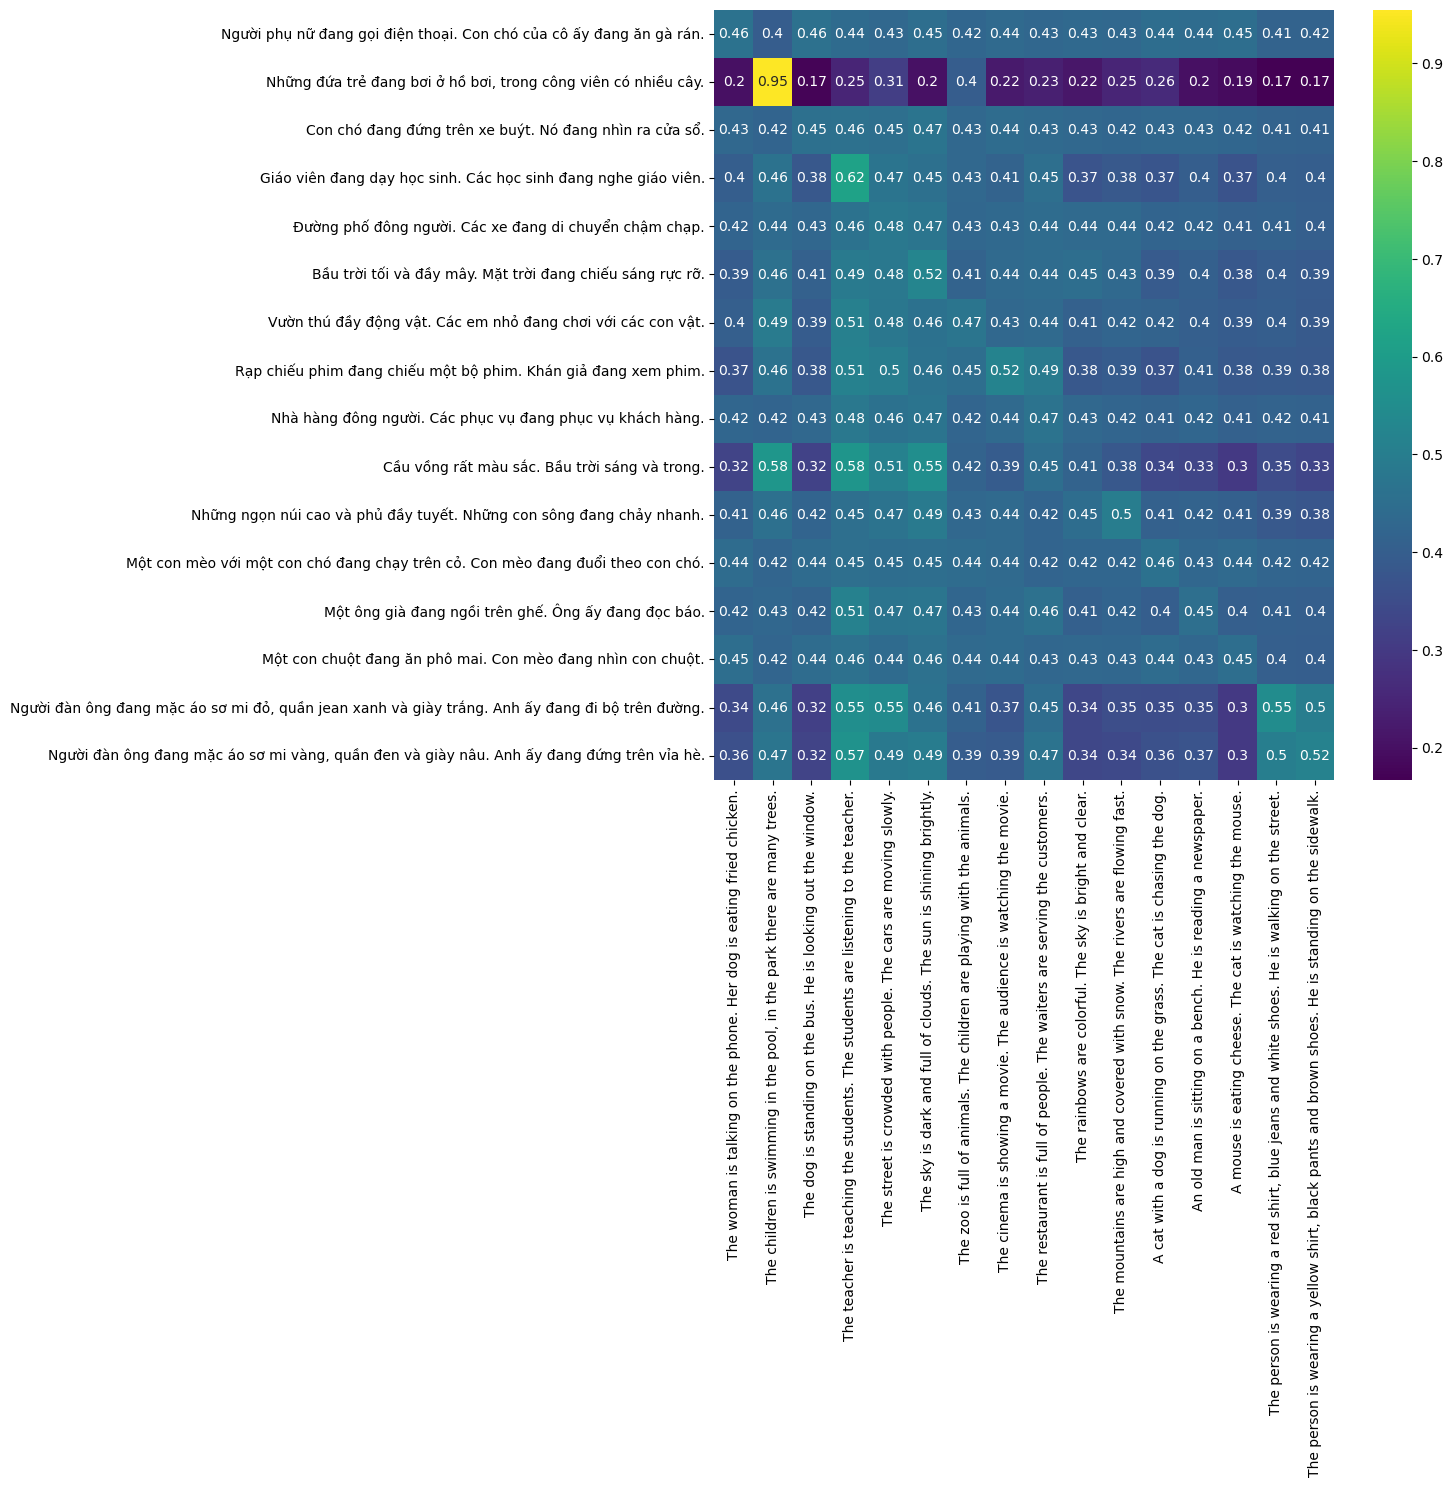

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.heatmap(table_result**(30/100), annot=True, cmap='viridis')